# Causal Lab: ATE Recovery Under Controlled DGP with Observable Confounders

This notebook evaluates five causal estimators on their ability to recover a
known average treatment effect (ATE) from synthetic data. All data is generated
from controlled DGPs where the true ATE is fixed at $2.0$ and all relevant
covariates are observed by construction. The question is not whether we have the
right variables (we do!) but whether standard methods can exploit them correctly
under different structural conditions.

This is the selection-on-observables setting. There are no unobserved confounders,
no instruments, no panel structure. Just $X$, $T$, and $Y$, and the challenge of
recovering the causal effect of $T$ on $Y$ when the assignment mechanism and
outcome surface take different forms. Even in this idealised setting, naive methods
fail. The scenarios below show how and why.

---

## Scenarios

We examine three DGP scenarios, each isolating a distinct source of estimator
stress:

1. **Overlap Degradation** — treatment assignment propensity becomes increasingly
   deterministic as a function of covariates, degrading the common support region
   required for credible comparisons between treated and untreated units.

2. **Outcome Nonlinearity** — the outcome surface transitions from purely linear
   to fully nonlinear via a mixing parameter, stress testing estimators
   that rely on correct functional form specification.

3. **High Dimensionality** — TBC

Each scenario introduces a single knob that modulates intensity from mild to
severe, holding everything else fixed. This allows estimator failures to be
attributed cleanly to the structural feature under study.

All DGP functions are implemented in `src/dgp_functions.py` and imported into the notebook at the
start of each scenario section.

---

## Estimator Suite

We evaluate five estimators spanning the spectrum from naive baselines to doubly robust and cross-fitted methods, chosen to represent increasing levels of robustness to DGP misspecification.

- **Ordinary Least Squares (OLS)** regresses $Y$ on $T$ and $X$ using `statsmodels.OLS` and reads off
  the coefficient on $T$. It is the natural econometric baseline: include all
  controls in a linear model and assume the functional form is correct. It uses
  no propensity score and assumes the confounding relationship is additive and
  linear.

- **Inverse Probability Weighting (IPW)** estimates propensity scores using `sklearn.LogisticRegression` and
  constructs Horvitz-Thompson weights. Each unit's outcome is upweighted by the
  inverse of its treatment probability, rebalancing the sample so treated and
  control groups look comparable on average. It uses no outcome model. Propensity
  scores are clipped to $[0.05, 0.95]$ to prevent weight explosion near the
  boundary.

- **Flexible Regression Outcome (RO)** is a T-learner built on two `sklearn.RandomForestRegressor`
  models, one trained on treated units and one on controls. Predicted potential
  outcomes are generated for every unit under both treatment values and the ATE
  is their average difference. It allows a flexible, nonparametric outcome surface
  but applies no correction for selection into treatment.

- **Augmented IPW (AIPW)** is implemented via `econml.dr.LinearDRLearner` with a
  `LogisticRegression` propensity model and `LassoCV` outcome model. It augments
  the IPW estimator with an outcome model correction, making it doubly robust:
  consistent if either the propensity or outcome model is correctly specified.
  Cross-fitting across five folds is handled internally by `econml`.

- **Double Machine Learning (DML)** is implemented via `econml.dml.LinearDML` with `LassoCV` for both
  outcome and treatment nuisance models. Rather than reweighting by propensity
  scores, it partials out the effect of $X$ from both $Y$ and $T$ separately
  using cross-fitted regressions, then estimates the treatment effect on the
  residuals. This avoids direct propensity weighting and is designed to handle
  high-dimensional and nonlinear nuisance functions.

Specifications are fixed across all scenarios so that
any differences in performance are attributable to the estimator, not tuning
choices.

All estimators are implemented in `src/ate_suite.py` and share the interface
`fn(Y, T, X) -> float`. 

---

## Key Findings

- **Scenario 1: Overlap Degradation**  — 
When overlap is healthy all five estimators recover the true ATE reasonably well.
As overlap degrades, estimators fail in distinct and revealing ways. Flexible RO
accumulates the largest bias: without any selection correction, its outcome models
extrapolate across covariate regions they were never trained on. IPW fails through
weight explosion: as propensity scores polarise, a shrinking set of boundary units
dominates the estimate, producing both bias and variance. AIPW preserves near-zero
bias throughout but variance inflates sharply at high $\gamma$, making it
unreliable on any single dataset even when correct on average. OLS and DML are the
most resilient — OLS because the primary confounder enters linearly and is directly
controlled, DML because it avoids propensity weighting entirely through residualisation.

- **Scenario 2: Outcome Nonlinearity** — 
When the outcome surface is linear all estimators perform well. As nonlinearity
increases via $\alpha$, estimators diverge in a pattern driven by their outcome
model design. OLS accumulates bias steadily as functional form misspecification
grows, explaining only half the outcome variance by $\alpha=1.0$. Flexible RO
improves relative to OLS as nonlinearity increases, its random forest outcome
models better suited to complex surfaces despite ignoring the selection mechanism.
IPW is largely unaffected, relying on no outcome model at all. DML with linear
nuisance models degrades unexpectedly, revealing that its performance is contingent
on first-stage model quality rather than the cross-fitting procedure alone. Replacing
the LassoCV nuisance model with a random forest recovers near-zero bias throughout,
confirming that DML is only as good as the models it partials out with.

- **Scenario 3:** TBC


In [1]:
import numpy as np

TRUE_ATE = 2.0
SEED=89

## Scenario 1: Overlap Degradation

A core assumption in the selection-on-observables framework is that every unit
has a non-zero probability of receiving either treatment value, given its
covariates. This is the overlap assumption, sometimes called positivity. When it
holds, treated and untreated units with similar covariate profiles can be
meaningfully compared. When it fails, estimators are forced to extrapolate across
regions of covariate space where one group is absent, and any estimate of the
treatment effect becomes unreliable regardless of how sophisticated the method is.

We degrade overlap via a single parameter $\gamma$ that scales the log-odds of
treatment assignment. At low $\gamma$ treatment is close to random. As $\gamma$
increases assignment becomes increasingly deterministic, pushing propensity scores
toward 0 and 1 and shrinking the region of common support.

The sections below set out the DGP, the distribution of propensity scores across
$\gamma$ values, and estimator performance in terms of bias and RMSE.

### 1a - Data Generating Process

The DGP for this scenario is implemented in `make_overlap_dgp` in `src/dgp_functions.py`,
accepting `n`, `gamma`, `true_ate`, and `seed` and returning `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{10}$ drawn independently from $\mathcal{N}(0,1)$,
with distinct roles across models:

- $X_0$ — shared confounder, enters both treatment and outcome
- $X_4$, $X_5$ — treatment only
- $X_1$, $X_2$, $X_3$ — outcome only
- $X_6$ through $X_9$ — inactive noise

**Treatment assignment** via a logistic propensity model scaled by $\gamma$:

$$ps_i = \sigma\bigl(\gamma \cdot (X_{i0} + 0.3\, X_{i4} - 0.2\, X_{i5})\bigr), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

At $\gamma=1$ propensity scores spread across $(0,1)$ with meaningful overlap.
As $\gamma$ increases scores polarise toward 0 and 1. We evaluate eight values
$\gamma \in \{0.1, 0.25, 0.5, 0.75, 1, 1.5, 2.5, 5\}$ spanning near-random
to near-deterministic assignment.

**Outcome** is nonlinear in covariates but fixed across all $\gamma$:

$$Y_i = 2.0 \cdot T_i + 3X_{i0} + 2X_{i1}^2 + 1.5\, X_{i0} X_{i2} + 2\sin(X_{i3}) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

The nonlinear outcome terms mean all estimators face some functional form
challenge throughout, but overlap degradation via $\gamma$ is the sole source
of variation across scenarios.

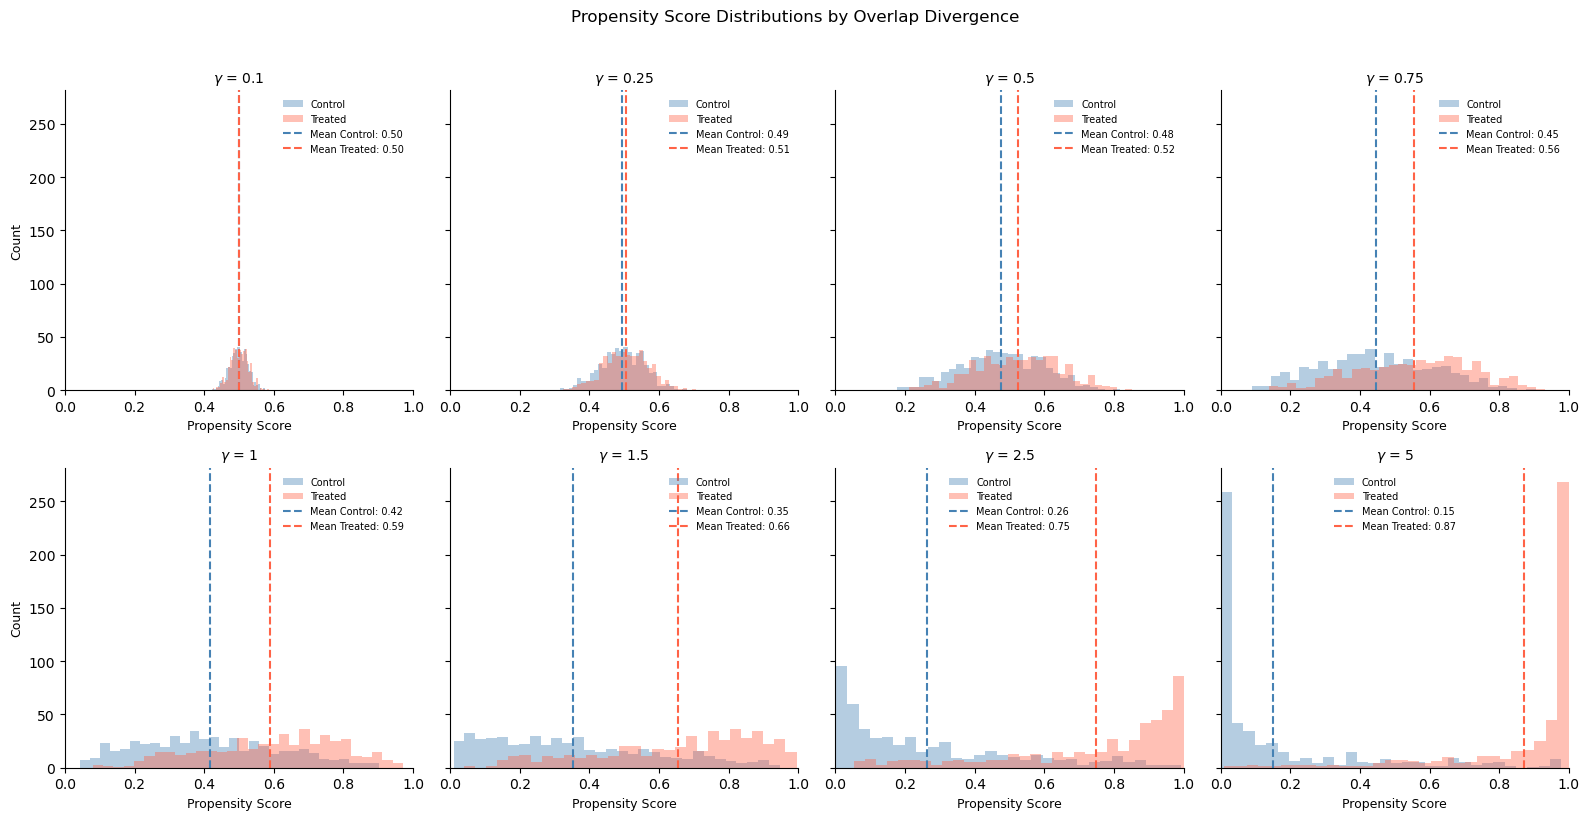

In [2]:
import sys
sys.path.append("src")
from dgp_functions import make_overlap_dgp, TRUE_ATE, SEED
import matplotlib.pyplot as plt

N      = 1000

# gamma values defining the overlap degradation spectrum
GAMMAS = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2.5, 5]

# plot propensity score distributions for treated and control at each gamma
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

for ax, gamma in zip(axes, GAMMAS):
    Y, T, X, ps = make_overlap_dgp(gamma=gamma, seed=SEED)

    mean_ctrl    = ps[T == 0].mean()
    mean_treated = ps[T == 1].mean()

    ax.hist(ps[T == 0], bins=30, alpha=0.4, label="Control",
            color="steelblue", edgecolor="none")
    ax.hist(ps[T == 1], bins=30, alpha=0.4, label="Treated",
            color="tomato", edgecolor="none")
    ax.axvline(mean_ctrl, color="steelblue", linewidth=1.5, linestyle="--",
               label=f"Mean Control: {mean_ctrl:.2f}")
    ax.axvline(mean_treated, color="tomato", linewidth=1.5, linestyle="--",
               label=f"Mean Treated: {mean_treated:.2f}")
    ax.set_title(f"$\\gamma$ = {gamma}", fontsize=10)
    ax.set_xlabel("Propensity Score", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Count", fontsize=9)
axes[4].set_ylabel("Count", fontsize=9)

# finalise layout and save
fig.suptitle("Propensity Score Distributions by Overlap Divergence", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_propensity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

At $\gamma=0.1$ both groups are essentially indistinguishable — mean propensity
scores of $0.50$ for control and $0.50$ for treated, with distributions tightly
overlapping near $0.5$. By $\gamma=1$ the means have separated to $0.42$ and
$0.59$. At $\gamma=2.5$ they stand at $0.26$ and $0.75$, and by $\gamma=5$ the
groups have almost entirely retreated to opposite ends of the score distribution
at $0.15$ and $0.87$. The common support region where both groups have
meaningful representation has effectively collapsed.

### 1b - Simulation & Results

With the DGP in place we run all five estimators across each of the eight
$\gamma$ values. For each combination we generate $N=50$ independent datasets
by varying the random seed, run every estimator on each dataset, and aggregate
results.

Results are summarised in per-gamma tables below, followed by bias and RMSE
curves across the full $\gamma$ spectrum.

In [3]:
import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm
from ate_suite import ESTIMATORS
import warnings
warnings.filterwarnings("ignore")

N_SIMS = 50

# run all estimators across each gamma value for a single simulation draw
def run_sim(sim):
    rows = []
    for gamma in GAMMAS:
        Y, T, X, ps = make_overlap_dgp(gamma=gamma, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "gamma"    : gamma,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

# parallelise across simulation draws using all available CPU cores
results = Parallel(n_jobs=-1)(
    delayed(run_sim)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

# flatten results and compute bias and squared error against true ATE
records = [row for batch in results for row in batch]

df = pd.DataFrame(records)
df["bias"]     = df["estimate"] - TRUE_ATE
df["sq_error"] = df["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:55<00:00,  1.10s/it]


The simulation loop runs all five estimators across each value of $\gamma$ over $N=50$ draws, averaging results to produce stable bias and RMSE estimates. Results are reported as per-gamma summary tables followed by a visual comparison across the full overlap degradation spectrum.

In [4]:
# aggregate estimates across simulations by gamma and estimator
summary = (
    df.groupby(["gamma", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)
# display per-gamma summary tables
for gamma in GAMMAS:
    subset = summary[summary["gamma"] == gamma].drop(columns="gamma")
    subset = subset.set_index("estimator")
    print(f"\nγ = {gamma}")
    display(subset)


γ = 0.1


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.980,-0.020,0.053,0.228
DML,2.000,-0.000,0.047,0.215
Flexible RO,2.018,0.018,0.011,0.105
IPW,1.990,-0.010,0.047,0.215
OLS,1.988,-0.012,0.046,0.214



γ = 0.25


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.002,0.002,0.050,0.221
DML,2.002,0.002,0.048,0.217
Flexible RO,2.043,0.043,0.012,0.118
IPW,1.991,-0.009,0.047,0.214
OLS,1.988,-0.012,0.045,0.211



γ = 0.5


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.989,-0.011,0.133,0.361
DML,1.964,-0.036,0.068,0.261
Flexible RO,2.459,0.459,0.038,0.498
IPW,2.220,0.220,0.156,0.449
OLS,1.967,-0.033,0.064,0.252



γ = 2.5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.900,-0.100,0.106,0.338
DML,1.944,-0.056,0.070,0.268
Flexible RO,2.833,0.833,0.044,0.859
IPW,2.719,0.719,0.095,0.781
OLS,1.949,-0.051,0.062,0.251



γ = 5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.774,-0.226,0.087,0.369
DML,1.984,-0.016,0.085,0.290
Flexible RO,3.548,1.548,0.044,1.562
IPW,3.419,1.419,0.072,1.444
OLS,1.991,-0.009,0.078,0.276


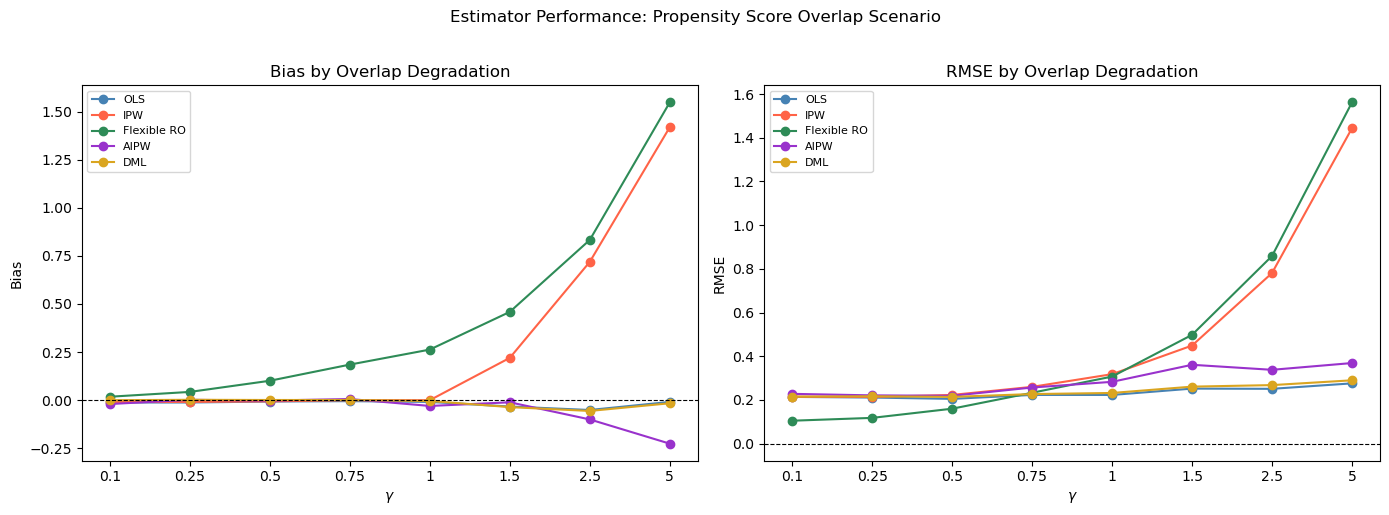

In [5]:
# consistent colour mapping across all scenario plots
estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map = dict(zip(estimator_order, colors))

x_pos    = list(range(len(GAMMAS)))
x_labels = [str(g) for g in GAMMAS]

# plot bias and RMSE across gamma values for each estimator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary[summary["estimator"] == name].sort_values("gamma")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Overlap Degradation")
    ax.legend(fontsize=8)

plt.suptitle("Estimator Performance: Propensity Score Overlap Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

The bias chart reveals a clear separation between estimators as overlap degrades.
At low $\gamma$ all five estimators recover the true ATE reasonably well. Beyond
$\gamma=1$ the picture diverges sharply.

- **Flexible RO** accumulates the largest bias under overlap failure, more than
  IPW. This is likely since forests do not extrapolate beyond their training support — they
  return leaf averages from the nearest observed region. At high $\gamma$ the
  treated and control covariate distributions are nearly disjoint. Predicting
  $Y(1)$ for a control unit means querying a forest trained almost entirely on
  a different region of covariate space. The returned predictions are therefore
  systematically wrong not because the model is misspecified but because the
  required counterfactual lies outside the observed data.

- **IPW** fails for a different reason. As propensity scores polarise toward 0
  and 1, inverse weights explode. Even with clipping, the effective sample
  collapses to a thin set of boundary units that carry disproportionate influence.
  The ATE is no longer an average over the full population but over a small,
  unrepresentative slice of it.

- **OLS** holds up because it never touches propensity scores. It controls for
  $X_0$ directly as a covariate, which absorbs most of the confounding signal
  regardless of how separated the groups become. Outcome model misspecification
  introduces modest bias but overlap degradation does not break it.

- **DML** avoids propensity weighting entirely by partialling out treatment and
  outcome on $X$ before estimating the effect. The residualised problem is much
  less sensitive to distributional separation between groups, which is why bias
  stays near zero and RMSE remains tight across the full $\gamma$ range.

- **AIPW** keeps bias controlled but variance grows at high $\gamma$. The outcome
  model does the heavy lifting on confounding, but the IPW correction term
  amplifies noise as weights become extreme. The widening gap between bias and
  RMSE is therefore due to the instability introduced by the extreme propensity weights.

### 1c - Diagnostics: Propensity Reliant Estimators

The bias and RMSE curves tell us *that* estimators fail but not always *why*.
Two further diagnostics ground the failures mechanically. 

We focus on IPW and
AIPW: the two estimators that explicitly construct and invert propensity scores
as part of their estimation procedure. DML also models the treatment as a function
of $X$ but never converts those predictions into inverse weights, insulating it
from the instability examined here.


### 1c(i) - IPW Weight Instability

We estimate propensity scores using the same logistic regression specification as
the IPW estimator and compute inverse probability weights for each unit. For
treated units the weight is $1/\hat{ps}_i$ and for control units $1/(1-\hat{ps}_i)$.
Weights are clipped to $[0.05, 0.95]$ consistent with the estimator. The
histograms below show the full weight distribution across all units at each
$\gamma$ value. A tight distribution near $2.0$ indicates balanced groups and
stable reweighting. A heavy right tail indicates a small number of units carrying
disproportionate influence over the final estimate.

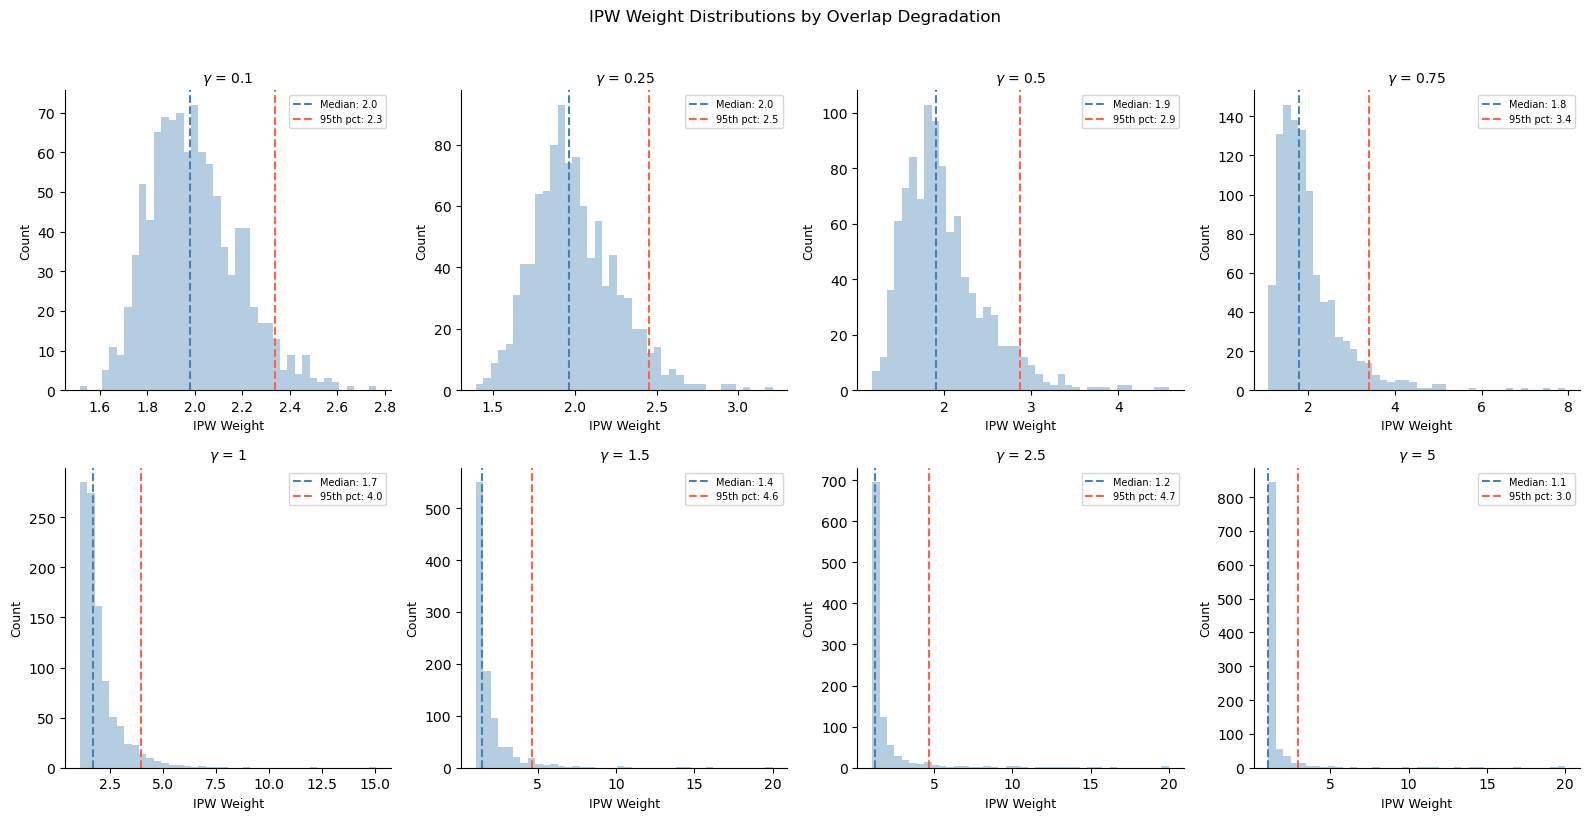

In [6]:
from sklearn.linear_model import LogisticRegression
from ate_suite import PS_CLIP, SEED

# estimate propensity scores and compute IPW weights at each gamma value
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for ax, gamma in zip(axes, GAMMAS):
    Y, T, X, ps = make_overlap_dgp(gamma=gamma)
    ps_hat = (
        LogisticRegression(random_state=SEED)
        .fit(X, T)
        .predict_proba(X)[:, 1]
    )
    ps_hat  = np.clip(ps_hat, *PS_CLIP)
    weights = T / ps_hat + (1 - T) / (1 - ps_hat)

    ax.hist(weights, bins=40, color="steelblue", alpha=0.4, edgecolor="none")
    ax.axvline(np.median(weights), color="steelblue", linewidth=1.5,
               linestyle="--", label=f"Median: {np.median(weights):.1f}")
    ax.axvline(np.percentile(weights, 95), color="tomato", linewidth=1.5,
               linestyle="--", label=f"95th pct: {np.percentile(weights, 95):.1f}")
    ax.set_title(f"$\\gamma$ = {gamma}", fontsize=10)
    ax.set_xlabel("IPW Weight", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    
# finalise layout and save
fig.suptitle("IPW Weight Distributions by Overlap Degradation", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_ipw_weights.png", dpi=150, bbox_inches="tight")
plt.show()

At $\gamma=0.1$ weights cluster tightly near $2.0$ and the 95th percentile sits
at $2.3$. By $\gamma=1$ the distribution has collapsed toward the clipping
boundary with a heavy right tail and the 95th percentile at $4.0$. A small number
of high-leverage units are doing most of the work.

This is what drives the IPW bias curve in section 1b. As the weight distribution
becomes more extreme, the estimator is effectively averaging over a shrinking and
unrepresentative subset of the sample rather than the full population.

### 1c(ii) - Simulation Traces: AIPW vs IPW

Each blue trace represents one of the $N=50$ simulation draws, showing the
estimator's ATE estimate across the eight $\gamma$ values for that particular
dataset. The red line is the mean estimate across all draws. The dashed line
marks the true ATE of $2.0$.

Where traces are tightly bundled around the mean the estimator is stable across
datasets. Where they fan out the estimator is sensitive to the specific random
realisation of the DGP i.e. the same method applied to a different sample of the
same population would give a meaningfully different answer. This distinguishes
variance from bias: a mean that drifts from $2.0$ indicates bias, while a
widening fan around a stable mean indicates variance inflation.

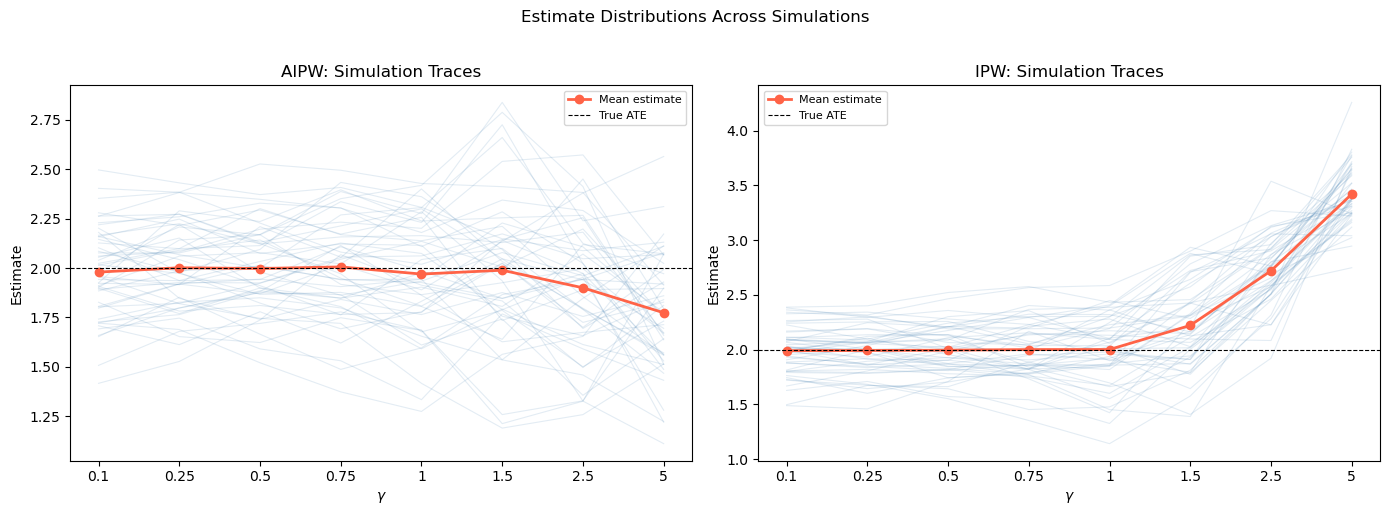

In [7]:
# plot individual simulation traces and mean estimate for AIPW and IPW
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["AIPW", "IPW"]):
    traces = df[df["estimator"] == name].sort_values("gamma")
    for sim in traces["sim"].unique():
        sim_data = traces[traces["sim"] == sim]
        ax.plot(x_pos, sim_data["estimate"].values,
                color="steelblue", alpha=0.15, linewidth=0.8)
    means = traces.groupby("gamma")["estimate"].mean().values
    ax.plot(x_pos, means, color="tomato", linewidth=2,
            marker="o", label="Mean estimate")
    ax.axhline(TRUE_ATE, color="black", linewidth=0.8,
               linestyle="--", label="True ATE")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Estimate")
    ax.set_title(f"{name}: Simulation Traces")
    ax.legend(fontsize=8)

plt.suptitle("Estimate Distributions Across Simulations", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_sim_traces.png", dpi=150, bbox_inches="tight")
plt.show()

The simulation traces contrast two different failure modes. 

- AIPW keeps its mean
estimate anchored near the true ATE of $2.0$ across all $\gamma$ values, as the
outcome model absorbs the confounding signal and the doubly robust correction
stays honest on average. But the individual traces fan out dramatically above
$\gamma=1.5$, revealing substantial variance inflation driven by the same weight
instability visible in the IPW weight plots. 
- IPW tells a different story: both
the mean and the individual traces drift upward together, reflecting systematic
bias rather than noise. The distinction matters since AIPW is getting the right answer
on average but becoming an unreliable tool for any single dataset, while IPW is
getting the wrong answer consistently.

## Scenario 2: Outcome Nonlinearity

The selection-on-observables framework assumes estimators can adequately model
the relationship between covariates and outcomes. When that relationship is linear,
OLS is correctly specified and has a natural advantage. But real outcome surfaces
are rarely linear. In this scenario we ask what happens when the outcome model
becomes progressively more complex — holding treatment assignment fixed with
healthy overlap throughout so that nonlinearity is the only active stressor.

We introduce a mixing parameter $\alpha$ that interpolates between a purely linear
and a fully nonlinear outcome surface. At $\alpha=0$ OLS is correctly specified
and all estimators operate in a benign setting. As $\alpha$ increases the outcome
surface accumulates oscillating, cubic, localised, and interaction terms that no
linear model can approximate well globally.

The sections below set out the DGP, the outcome surface across $\alpha$ values,
and estimator performance in terms of bias and RMSE.

### 2a - Data Generating Process

The DGP for this scenario is implemented in `make_nonlinear_dgp` in `src/dgp_functions.py`,
accepting `n`, `alpha`, `true_ate`, and `seed` and returning `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{10}$ drawn independently from $\mathcal{N}(0,1)$,
with distinct roles across models:

- $X_0$ — shared confounder, enters both treatment and outcome
- $X_4$, $X_5$ — treatment only
- $X_1$, $X_2$, $X_3$, $X_6$, $X_7$, $X_8$ — outcome only
- $X_9$ — inactive noise

**Treatment assignment** — fixed logistic propensity model with healthy overlap
held constant throughout so that overlap is never the source of stress:

$$ps_i = \sigma(X_{i0} + 0.3\, X_{i4} - 0.2\, X_{i5}), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

**Outcome** — interpolates between a linear and a nonlinear surface via $\alpha$:

$$Y_i = 2.0 \cdot T_i + (1-\alpha) \cdot f_{\text{linear}}(X_i) + \alpha \cdot f_{\text{nonlinear}}(X_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

where:

$$f_{\text{linear}}(X) = 3X_0 + 2X_1 + 1.5X_2$$

$$f_{\text{nonlinear}}(X) = 2\sin(X_0) + 0.4X_1^2 - 0.3X_2^3 + 1.5e^{-0.5(X_3^2 + X_4^2)} + 1.5\log(1 + |X_5 + X_6|) + X_7 X_8$$

We evaluate six values $\alpha \in \{0, 0.2, 0.4, 0.6, 0.8, 1.0\}$. At $\alpha=0$
OLS is correctly specified. At $\alpha=1$ the surface combines oscillation,
polynomial curvature, a localised Gaussian bump, log compression, and a bilinear
interaction. Functional form complexity via $\alpha$ is the sole source of
variation across scenarios.

We consider six values of $\alpha \in \{0, 0.2, 0.4, 0.6, 0.8, 1.0\}$ spanning
the transition from a correctly specified linear outcome to a fully nonlinear
surface. To show what $\alpha$ is actually doing to the outcome surface, we fit
OLS directly on $f(X)$ — the true outcome surface excluding the treatment effect
and noise — and report $R^2$ at each $\alpha$ value. At $\alpha=0$ OLS fits
perfectly by construction. As $\alpha$ increases the nonlinear terms activate
and OLS progressively loses its grip on the outcome surface, falling to $R^2
\approx 0.5$ at full nonlinearity.

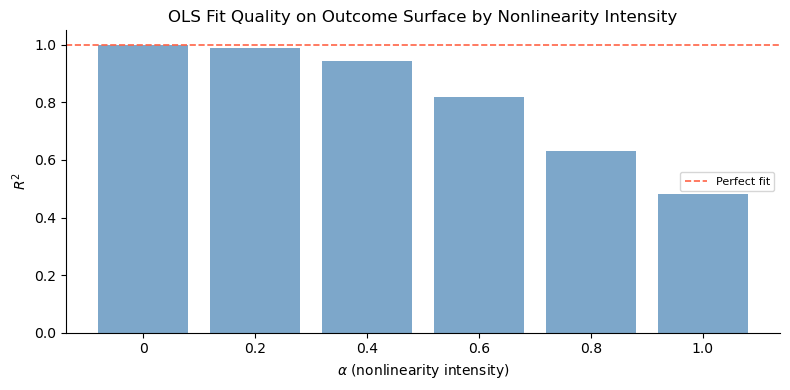

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from dgp_functions import make_nonlinear_dgp

# alpha values defining the degree of nonlinearity
ALPHAS = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

# compute OLS R² on the true outcome surface at each alpha value
r2_scores = []

for alpha in ALPHAS:
    Y, T, X, ps = make_nonlinear_dgp(alpha=alpha)
    f_linear = 3 * X[:, 0] + 2 * X[:, 1] + 1.5 * X[:, 2]
    f_nonlinear = (
        2.0 * np.sin(X[:, 0])
        + 0.4 * X[:, 1]**2
        - 0.3 * X[:, 2]**3
        + 1.5 * np.exp(-0.5 * (X[:, 3]**2 + X[:, 4]**2))
        + 1.5 * np.log1p(np.abs(X[:, 5] + X[:, 6]))
        + 1.0 * X[:, 7] * X[:, 8]
    )
    f_true = (1 - alpha) * f_linear + alpha * f_nonlinear
    f_hat  = LinearRegression().fit(X, f_true).predict(X)
    r2_scores.append(r2_score(f_true, f_hat))

# plot R² by nonlinearity intensity to show OLS fit degradation
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(a) for a in ALPHAS], r2_scores, color="steelblue", alpha=0.7, edgecolor="none")
ax.set_xlabel(r"$\alpha$ (nonlinearity intensity)")
ax.set_ylabel("$R^2$")
ax.set_title("OLS Fit Quality on Outcome Surface by Nonlinearity Intensity")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="tomato", linewidth=1.2, linestyle="--", label="Perfect fit")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("images/nonlinear_r2.png", dpi=150, bbox_inches="tight")
plt.show()

By $\alpha=1.0$ OLS can explain only around half the variance in the outcome
surface despite observing all ten covariates. This is the functional form
misspecification that the estimator results in section 2b will reflect.

### 2b - Simulation & Results

We run all five estimators across each $\alpha$ value over $N=50$ simulation
draws, varying the random seed across draws to produce stable bias and RMSE
estimates. Treatment assignment is identical across all $\alpha$ values — only
the outcome surface changes. Any divergence in estimator performance is therefore
attributable solely to functional form complexity.

In [9]:
N_SIMS  = 50

# run all estimators across each alpha value for a single simulation draw
def run_sim_nl(sim):
    rows = []
    for alpha in ALPHAS:
        Y, T, X, ps = make_nonlinear_dgp(alpha=alpha, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "alpha"    : alpha,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

# parallelise across simulation draws using all available CPU cores
results = Parallel(n_jobs=-1)(
    delayed(run_sim_nl)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

# flatten results and compute bias and squared error against true ATE
records_nl = [row for batch in results for row in batch]

df_nl = pd.DataFrame(records_nl)
df_nl["bias"]     = df_nl["estimate"] - TRUE_ATE
df_nl["sq_error"] = df_nl["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s]


In [10]:
# aggregate estimates across simulations by alpha and estimator
summary_nl = (
    df_nl.groupby(["alpha", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)
# display per-alpha summary tables
for alpha in ALPHAS:
    subset = summary_nl[summary_nl["alpha"] == alpha].drop(columns="alpha")
    subset = subset.set_index("estimator")
    print(f"\nalpha = {alpha}")
    display(subset)


alpha = 0


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.998,-0.002,0.005,0.067
DML,1.998,-0.002,0.005,0.068
Flexible RO,2.278,0.278,0.013,0.299
IPW,2.019,0.019,0.019,0.136
OLS,1.996,-0.004,0.004,0.062



alpha = 0.2


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.004,0.004,0.006,0.077
DML,2.016,0.016,0.006,0.078
Flexible RO,2.193,0.193,0.010,0.217
IPW,2.020,0.020,0.015,0.124
OLS,2.011,0.011,0.005,0.072



alpha = 0.4


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.016,0.016,0.014,0.117
DML,2.050,0.050,0.012,0.121
Flexible RO,2.084,0.084,0.009,0.126
IPW,2.023,0.023,0.014,0.120
OLS,2.043,0.043,0.011,0.114



alpha = 0.8


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.022,0.022,0.020,0.143
DML,2.068,0.068,0.017,0.147
Flexible RO,2.055,0.055,0.011,0.119
IPW,2.024,0.024,0.017,0.129
OLS,2.059,0.059,0.016,0.140



alpha = 1.0


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.028,0.028,0.028,0.167
DML,2.085,0.085,0.023,0.174
Flexible RO,2.059,0.059,0.013,0.128
IPW,2.025,0.025,0.021,0.145
OLS,2.074,0.074,0.023,0.167


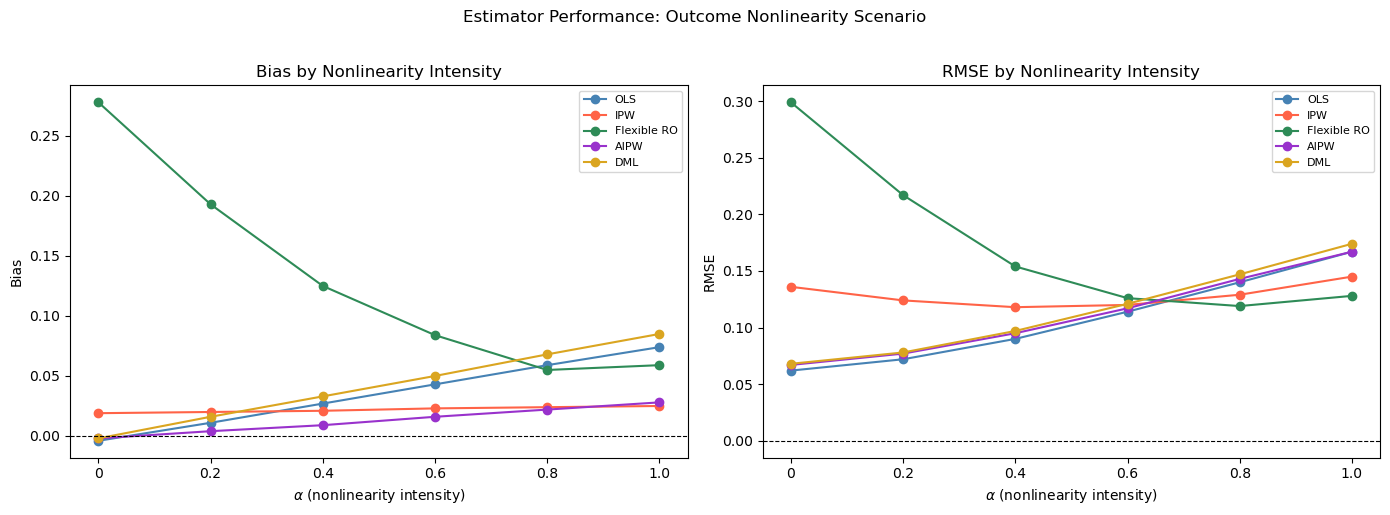

In [11]:
# consistent colour mapping across all scenario plots
estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors          = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map       = dict(zip(estimator_order, colors))

x_pos    = list(range(len(ALPHAS)))
x_labels = [str(a) for a in ALPHAS]

# plot bias and RMSE across alpha values for each estimator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary_nl[summary_nl["estimator"] == name].sort_values("alpha")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\alpha$ (nonlinearity intensity)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Nonlinearity Intensity")
    ax.legend(fontsize=8)

plt.suptitle("Estimator Performance: Outcome Nonlinearity Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/nonlinear_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

The results below reveal a different pattern from scenario 1. At $\alpha=0$ the
outcome is purely linear and estimators perform broadly as expected. As $\alpha$
increases and the outcome surface becomes progressively harder to approximate
linearly, the picture shifts in a revealing way.

- **Flexible RO** starts with elevated bias at $\alpha=0$ and improves as
  nonlinearity increases which may be somewhat counterintuitive. However, even when the
  outcome is purely linear, the T-learner's training subsamples are not random.
  The treated group skews toward high $X_0$ by construction, so each forest
  learns the outcome surface within a selected region and extrapolates when asked
  to predict counterfactuals elsewhere.

- **OLS** behaves exactly as expected with near-zero bias at $\alpha=0$ where it is
  correctly specified, then accumulating bias steadily as the nonlinear terms
  activate. By $\alpha=1.0$ it is explaining only around half the outcome variance
  and the bias is visible in the results.

- **IPW** is largely unaffected by outcome nonlinearity, which makes sense since it
  uses no outcome model at all. Its bias and RMSE stay relatively flat across
  $\alpha$ values, driven entirely by propensity estimation quality rather than
  the outcome surface.

- **DML** degrades more than expected at high $\alpha$. The nuisance outcome model
  is `LassoCV`, a linear method with regularisation. As the outcome surface becomes
  genuinely nonlinear, LassoCV cannot fit it well and the residualisation step
  becomes noisy, propagating into the treatment effect estimate. This is not a
  fundamental weakness of DML but a consequence of the nuisance model choice (as we explore further below).

- **AIPW** holds up best among the doubly robust methods. The propensity model
  provides a correction that partially compensates for outcome model misspecification,
  consistent with its doubly robust design.

*Note: Across both scenarios thus far, Flexible RO's failure mode is consistent: it is always a
support problem. In Scenario 1 the support failure comes from overlap degradation
separating the covariate distributions. In Scenario 2 it comes from selection into
treatment skewing the training sample even under a correctly specified linear
outcome. The T-learner has no mechanism to correct for either — it learns within
its observed support and predicts outside it.*

### 2c - Diagnostics: DML with Flexible Nuisance Models

The results in 2b show DML degrading at high $\alpha$ despite its cross-fitting
design. The likely reason behind this is the outcome nuisance model, `LassoCV`, which is a linear estimator and
cannot approximate a genuinely nonlinear outcome surface. DML is only as good as
its first stage. 

We rerun DML with `RandomForestRegressor` as the outcome nuisance
model and compare simulation traces against the original `LassoCV` specification
to isolate the effect of nuisance model choice.

In [12]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

# two DML variants: linear nuisance (LassoCV) vs flexible nuisance (Random Forest)
def dml_lasso(Y, T, X, seed=SEED):
    est = LinearDML(
        model_y=LassoCV(cv=5, random_state=seed),
        model_t=LassoCV(cv=5, random_state=seed),
        random_state=seed
    )
    est.fit(Y, T, X=X)
    return float(est.ate(X=X))

def dml_forest(Y, T, X, seed=SEED):
    est = LinearDML(
        model_y=RandomForestRegressor(n_estimators=100, random_state=seed),
        model_t=LassoCV(cv=5, random_state=seed),
        random_state=seed
    )
    est.fit(Y, T, X=X)
    return float(est.ate(X=X))

# simulation loop comparing both DML specifications across alpha values
def run_sim_2c(sim):
    rows = []
    for alpha in ALPHAS:
        Y, T, X, ps = make_nonlinear_dgp(alpha=alpha, seed=sim)
        rows.append({"alpha": alpha, "estimator": "DML (LassoCV)",
                     "sim": sim, "estimate": dml_lasso(Y, T, X)})
        rows.append({"alpha": alpha, "estimator": "DML (Forest)",
                     "sim": sim, "estimate": dml_forest(Y, T, X)})
    return rows

# parallelise across simulation draws
results_2c = Parallel(n_jobs=-1)(
    delayed(run_sim_2c)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

# flatten results and compute bias and squared error
records_2c = [row for batch in results_2c for row in batch]
df_2c      = pd.DataFrame(records_2c)
df_2c["bias"]     = df_2c["estimate"] - TRUE_ATE
df_2c["sq_error"] = df_2c["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]


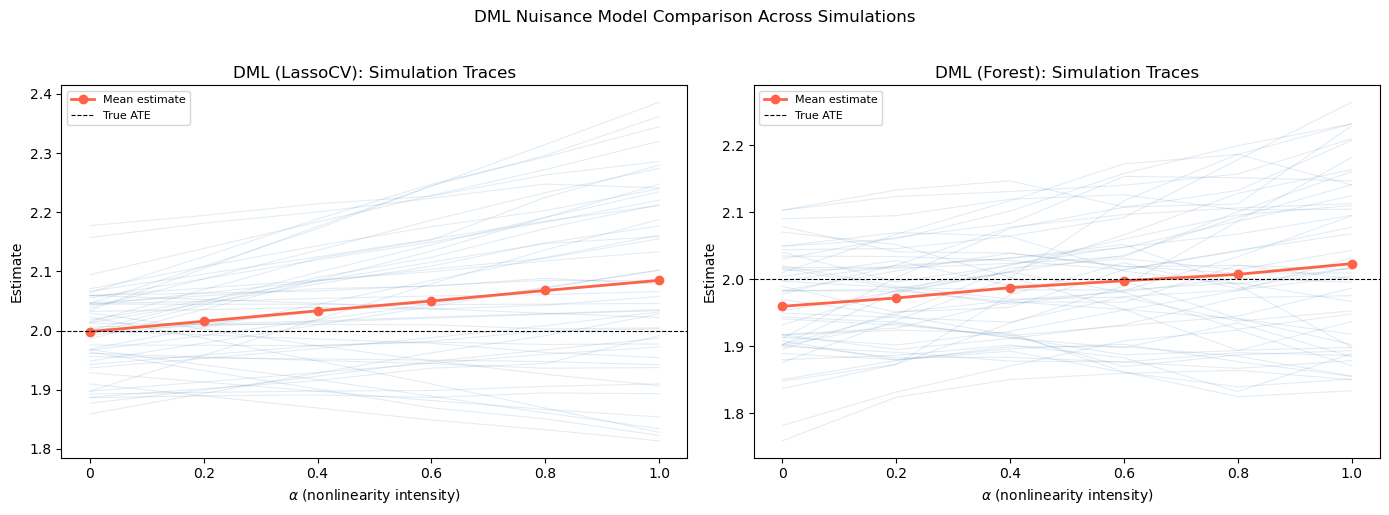

In [13]:
x_pos_nl    = list(range(len(ALPHAS)))
x_labels_nl = [str(a) for a in ALPHAS]

# plot simulation traces for DML (LassoCV) vs DML (Forest) across alpha values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["DML (LassoCV)", "DML (Forest)"]):
    traces = df_2c[df_2c["estimator"] == name].sort_values("alpha")
    for sim in traces["sim"].unique():
        sim_data = traces[traces["sim"] == sim]
        ax.plot(x_pos_nl, sim_data["estimate"].values,
                color="steelblue", alpha=0.15, linewidth=0.8)
    means = traces.groupby("alpha")["estimate"].mean().values
    ax.plot(x_pos_nl, means, color="tomato", linewidth=2,
            marker="o", label="Mean estimate")
    ax.axhline(TRUE_ATE, color="black", linewidth=0.8,
               linestyle="--", label="True ATE")
    ax.set_xticks(x_pos_nl)
    ax.set_xticklabels(x_labels_nl)
    ax.set_xlabel(r"$\alpha$ (nonlinearity intensity)")
    ax.set_ylabel("Estimate")
    ax.set_title(f"{name}: Simulation Traces")
    ax.legend(fontsize=8)

plt.suptitle("DML Nuisance Model Comparison Across Simulations", y=1.02)
plt.tight_layout()
plt.savefig("images/nonlinear_dml_traces.png", dpi=150, bbox_inches="tight")
plt.show()

Both specifications show considerable variation across individual simulation draws,
reflecting genuine estimation uncertainty with a complex outcome
surface. The distinction between them is in the mean estimate behaviour rather
than individual run stability.

- **DML (LassoCV)** shows a steadily drifting mean as $\alpha$ increases, with
  the trace fan widening and shifting upward. The linear nuisance model cannot
  approximate the nonlinear outcome surface and the residualisation step carries
  that misspecification into the treatment effect estimate.

- **DML (Forest)** keeps its mean estimate anchored near $2.0$ throughout. The
  individual traces are similarly noisy but the average across simulations does
  not drift, confirming that the degradation in section 2b was a nuisance model
  problem rather than a fundamental limitation of the DML approach.

The practical implication is straightforward: the choice of first-stage model in
DML matters. In settings where the outcome surface is likely nonlinear, a flexible
nuisance model should be preferred.

## Scenario 3: Covariate Dimensionality

In the previous two scenarios the covariate space was fixed at ten dimensions.
In practice, researchers often observe many more variables than are actually
relevant e.g. digital user activity datasets may contain hundreds or thousands of potential controls. Including all of them is the safe choice from an identification standpoint, but can create
estimation challenges that vary dramatically across methods.

In this scenario we increase the total number of covariates $p$ while holding
the number of truly informative covariates fixed at $k=5$. The remaining $p-k$
covariates are pure noise i.e. they have no relationship with treatment or outcome.
Treatment assignment and the outcome structure are held fixed throughout so that
dimensionality is the sole source of estimator stress.

The sections below set out the DGP, the noise-to-signal ratio across $p$ values,
and estimator performance in terms of bias and RMSE.

### 3a. Data Generating Process

The DGP for this scenario is implemented in `make_highdim_dgp` in `src/dgp_functions.py`,
accepting `n`, `p`, `k`, `true_ate`, and `seed` and returning `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{p}$ with two distinct groups:

- $X_0$ through $X_4$ — the $k=5$ informative covariates, drawn independently from $\mathcal{N}(0,1)$
- $X_5$ through $X_{p-1}$ — noise covariates, weakly correlated with $X_0$ via $\rho=0.3$

The noise covariates have no true effect on treatment or outcome but their
correlation with $X_0$ makes them look like confounders to naive methods. An
estimator that includes them without selection will absorb spurious signal and
inflate variance. An estimator with regularisation should down-weight or zero
them out.

**Treatment assignment** — driven by informative covariates only:

$$ps_i = \sigma(X_{i0} + 0.3\, X_{i1} - 0.2\, X_{i2}), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

**Outcome** — linear in the five informative covariates only:

$$Y_i = 2.0 \cdot T_i + 3X_{i0} + 2X_{i1} + 1.5X_{i2} + X_{i3} + 0.5X_{i4} + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

We evaluate six values $p \in \{5, 10, 50, 100, 200, 500\}$. At $p=5$ there
are no noise variables and all estimators operate cleanly. As $p$ grows the
noise pool expands and methods that cannot distinguish signal from correlated
noise begin to accumulate bias and variance.

In [14]:
from dgp_functions import make_highdim_dgp

DIMS = [5, 10, 50, 100, 200, 500]
K    = 5  # number of truly informative covariates, fixed throughout

Before running the estimators we visualise the noise-to-signal ratio across $p$
values. For each $p$ we fit a LassoCV model on $Y$ regressed on $X$ and plot
the proportion of selected variables that are genuinely informative versus noise.

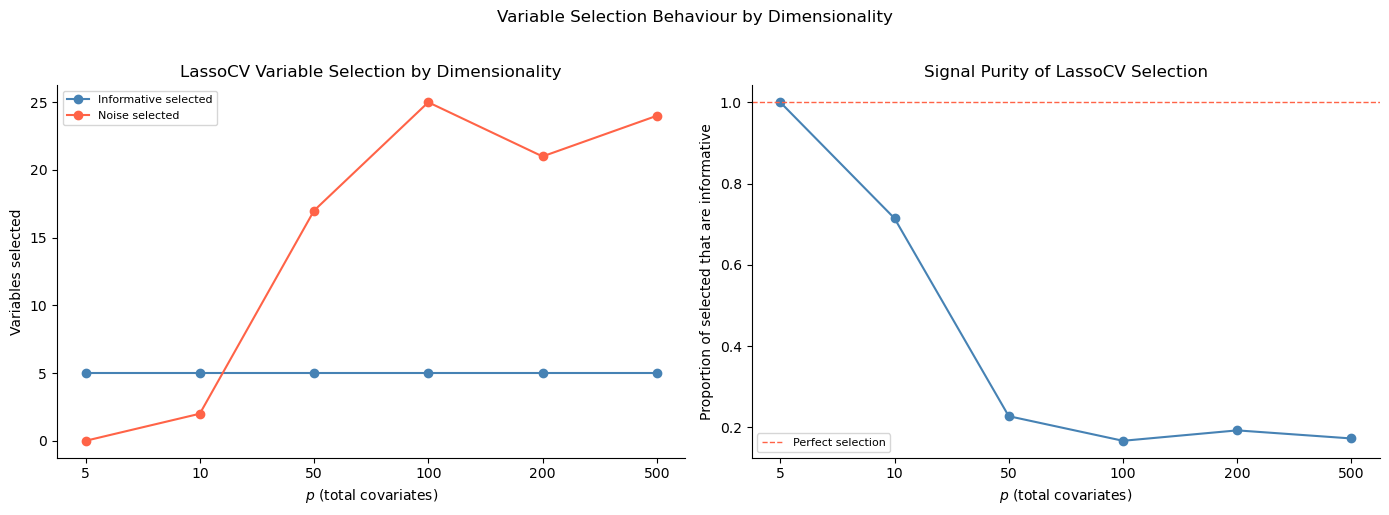

In [15]:
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
import numpy as np

# fit LassoCV at each p value and count informative vs noise variables selected
signal_ratios = []
noise_selected = []
signal_selected = []

for p in DIMS:
    Y, T, X, ps = make_highdim_dgp(p=p, k=K)
    lasso = LassoCV(cv=3, random_state=SEED).fit(X, Y)
    coefs = np.abs(lasso.coef_)
    selected = coefs > 0
    n_signal = selected[:K].sum()
    n_noise  = selected[K:].sum()
    signal_selected.append(n_signal)
    noise_selected.append(n_noise)
    signal_ratios.append(n_signal / max(selected.sum(), 1))
    
# plot variable selection counts and signal purity across dimensionality levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(DIMS)), signal_selected, marker="o",
             color="steelblue", label="Informative selected")
axes[0].plot(range(len(DIMS)), noise_selected, marker="o",
             color="tomato", label="Noise selected")
axes[0].set_xticks(range(len(DIMS)))
axes[0].set_xticklabels([str(p) for p in DIMS])
axes[0].set_xlabel("$p$ (total covariates)")
axes[0].set_ylabel("Variables selected")
axes[0].set_title("LassoCV Variable Selection by Dimensionality")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(range(len(DIMS)), signal_ratios, marker="o",
             color="steelblue")
axes[1].axhline(1.0, color="tomato", linewidth=1.0, linestyle="--",
                label="Perfect selection")
axes[1].set_xticks(range(len(DIMS)))
axes[1].set_xticklabels([str(p) for p in DIMS])
axes[1].set_xlabel("$p$ (total covariates)")
axes[1].set_ylabel("Proportion of selected that are informative")
axes[1].set_title("Signal Purity of LassoCV Selection")
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Variable Selection Behaviour by Dimensionality", y=1.02)
plt.tight_layout()
plt.savefig("images/highdim_variable_selection.png", dpi=150, bbox_inches="tight")
plt.show()

Lasso consistently recovers all five informative covariates across every $p$ value but signal purity falls and stabilises around $0.20$ at high $p$. 

Methods that use Lasso internally for nuisance estimation will inherit this noise contamination, while OLS includes all $p$ variables with
equal weight and no selection at all.

### 3b - Simulation & Results

We run all five estimators across each $p$ value over $N=50$ simulation draws.
The informative covariate set is fixed at $k=5$ throughout — only the noise
pool grows. Any divergence in estimator performance is attributable solely to
the curse of dimensionality and each method's ability to handle irrelevant
covariates.

In [ ]:
N_SIMS = 50

# run all estimators across each p value for a single simulation draw
def run_sim_hd(sim):
    rows = []
    for p in DIMS:
        Y, T, X, ps = make_highdim_dgp(p=p, k=K, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "p"        : p,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

# parallelise across simulation draws using all available CPU cores
results_hd = Parallel(n_jobs=-1)(
    delayed(run_sim_hd)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)
# flatten results and compute bias and squared error against true ATE
records_hd = [row for batch in results_hd for row in batch]
df_hd = pd.DataFrame(records_hd)
df_hd["bias"]     = df_hd["estimate"] - TRUE_ATE
df_hd["sq_error"] = df_hd["bias"] ** 2

Simulations:  32%|███▏      | 16/50 [01:22<02:56,  5.19s/it]

In [ ]:
# aggregate estimates across simulations by p and estimator
summary_hd = (
    df_hd.groupby(["p", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)
# display per-p summary tables
for p in DIMS:
    subset = summary_hd[summary_hd["p"] == p].drop(columns="p")
    subset = subset.set_index("estimator")
    print(f"\np = {p}")
    display(subset)


p = 5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.975,-0.025,0.005,0.077
DML,1.978,-0.022,0.006,0.079
Flexible RO,2.299,0.299,0.013,0.320
IPW,2.004,0.004,0.017,0.130
OLS,1.981,-0.019,0.005,0.074



p = 10


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.003,0.003,0.003,0.057
DML,1.988,-0.012,0.004,0.062
Flexible RO,2.345,0.345,0.013,0.362
IPW,2.023,0.023,0.016,0.129
OLS,1.990,-0.010,0.003,0.057



p = 50


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.291,0.291,0.274,0.594
DML,1.998,-0.002,0.006,0.077
Flexible RO,2.491,0.491,0.024,0.514
IPW,2.102,0.102,0.027,0.192
OLS,2.008,0.008,0.006,0.076



p = 200


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,346.673,344.673,1396193.905,1219.455
DML,1.985,-0.015,0.004,0.068
Flexible RO,2.479,0.479,0.023,0.502
IPW,2.184,0.184,0.028,0.247
OLS,2.002,0.002,0.005,0.067



p = 500


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2124.839,2122.839,1.092527e+07,3900.411
DML,2.000,0.000,6.000000e-03,0.074
Flexible RO,2.533,0.533,2.400000e-02,0.555
IPW,2.555,0.555,1.700000e-02,0.570
OLS,1.996,-0.004,1.100000e-02,0.103


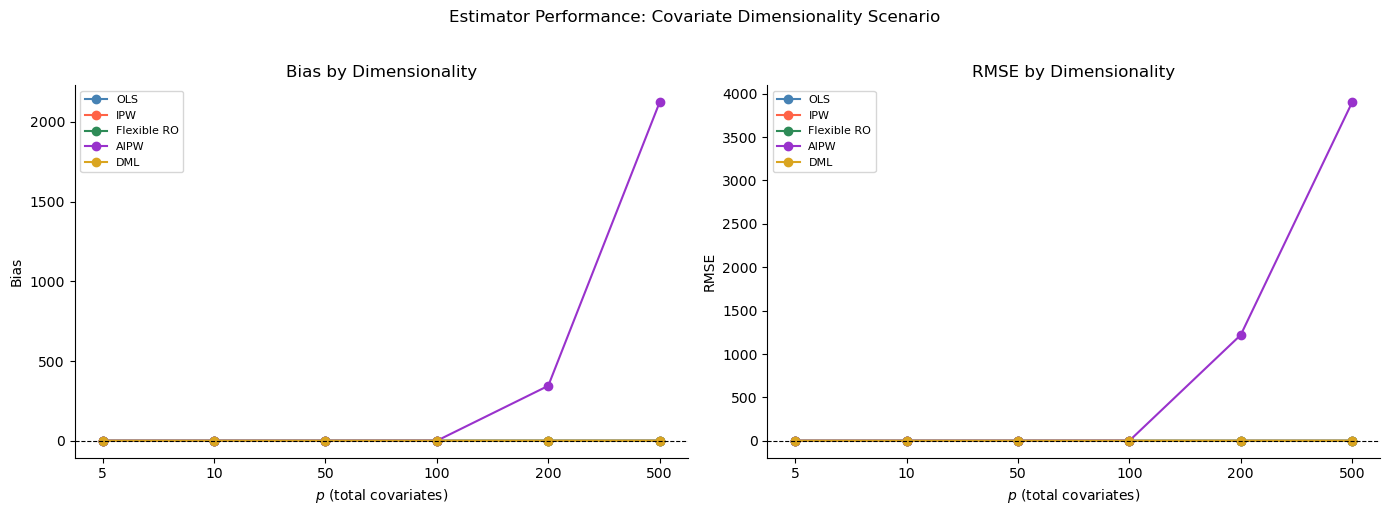

In [ ]:
# consistent colour mapping across all scenario plots
estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors          = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map       = dict(zip(estimator_order, colors))

x_pos    = list(range(len(DIMS)))
x_labels = [str(p) for p in DIMS]

# plot bias and RMSE across p values for each estimator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary_hd[summary_hd["estimator"] == name].sort_values("p")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("$p$ (total covariates)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Dimensionality")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Estimator Performance: Covariate Dimensionality Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/highdim_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print(df_hd[(df_hd["estimator"] == "AIPW") & (df_hd["p"] == 500)]["estimate"].describe())

count      50.000000
mean     2124.839225
std      3305.339302
min     -5483.837046
25%      -317.826481
50%      1967.261388
75%      4136.139440
max      9330.577959
Name: estimate, dtype: float64
